# 🤖 Comparing t-SNE and UMAP Dimension Reduction Models

In this walkthrough, I explore how to implement and compare two advanced dimensionality reduction algorithms—**t-SNE** and **UMAP**—using synthetic data. To provide a clear benchmark, I also compare these results against a standard **PCA** (Principal Component Analysis) reduction. 🧠

---

## 🎯 Objectives
After completing this analysis, I will be able to:
* 🛠️ **Apply** t-SNE and UMAP to feature space dimensionality reduction problems.
* 📐 **Use PCA** as a baseline comparison for evaluating the performance of non-linear algorithms.
* 🔍 **Analyze** how different models preserve data structure, such as cluster separation and relative density.

---

## 🏗️ Introduction

Dimensionality reduction is a critical step in visualizing high-dimensional datasets. While linear methods like PCA are efficient, they often fail to capture complex, non-linear relationships. In this study, I focus on two popular manifold learning techniques:

1.  **t-SNE (t-Distributed Stochastic Neighbor Embedding):** 🌀 Excellent at revealing local clusters by converting similarities between data points to joint probabilities.
2.  **UMAP (Uniform Manifold Approximation and Projection):** 🚀 A faster algorithm rooted in Riemannian geometry that often preserves more of the global data structure than t-SNE.

---

## 🧬 Methodology

### 1. Data Generation 🧪
I begin by generating a synthetic dataset of "blobs" within a **3D feature space** ($\mathbb{R}^3$). This 3D environment allows for an initial interactive exploration to understand the underlying clusters before I attempt to compress the manifold.

### 2. Dimensionality Reduction 📉
I project these 3D blobs into a **2D plane** using three distinct mathematical approaches:
* **PCA:** Linear orthogonal transformation.
* **t-SNE:** Non-linear local neighbor embedding.
* **UMAP:** Topological structure preservation.

### 3. Visual Evaluation 🎨
I color-code the clusters based on their original 3D labels to visually inspect the transformations:
* **Separation:** Do the clusters remain distinct in 2D?
* **Density:** Is the relative "tightness" of the data preserved?
* **Topology:** Does the 2D map reflect the true 3D spatial relationship?

---

## 📊 Comparison Matrix

| Feature | PCA 📏 | t-SNE 🌀 | UMAP ⚡ |
| :--- | :--- | :--- | :--- |
| **Model Type** | Linear Projection | Manifold Learning | Topological Mapping |
| **Global Structure** | ✅ Excellent | ❌ Poor | ✅ Good |
| **Execution Time** | 🏎️ Instant | ⏳ Intensive | 🚀 Fast |
| **Hyperparameters** | None | Perplexity | n_neighbors, min_dist |

---

> 💡 **Technical Note:** I've found that while **t-SNE** is great for "pretty" visualizations, **UMAP** is often my go-to for downstream machine learning pipelines because it is more computationally efficient and better at maintaining the distance between far-away clusters.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

import umap.umap_ as UMAP
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import plotly.express as px

# 🧬 Generating Synthetic 3D Data for Manifold Learning

In [6]:
# Create cluster centers
centers = [[2, -6, -6],
           [-1, 9,  4],
           [-8, 7,  2],
           [4, 7,  9]]
# Cluster standard deviation
cluster_std = [1, 1, 2, 3.5]

# Make the blobs and return the data and the blob labels
X, labels_ = make_blobs(n_samples=1000, centers=centers, n_features=3, cluster_std=cluster_std, random_state=42)

# 🌐 Interactive 3D Data Visualization

In [9]:
# Create a DataFrame for Plotly
df = pd.DataFrame(X, columns=['X', 'Y', 'Z'])

# Create interactive 3D scatter plot
fig = px.scatter_3d(df, x='X', y='Y', z='Z', color=labels_.astype(str) ,  opacity=0.7,  color_discrete_sequence=px.colors.qualitative.G10, title="3D Scatter Plot of Four Blobs")

fig.update_traces(marker=dict(size=5, line=dict(width=1, color='black')), showlegend=False)
fig.update_layout(coloraxis_showscale=False, width=1000, height=800)  # Remove color bar, resize plot

fig.show()

# 🔍 Analyzing and Preparing the Data

Now that I have the interactive plot running, I can dive deeper into the spatial relationships of my synthetic blobs. Interacting with the 3D space is essential because a static angle can often hide overlaps or clusters hiding behind one another. 🛰️

---

## 🧐 Exercise 1: My Observations of the 3D Blobs

By rotating and zooming into the interactive plot, I've noted several key characteristics about the data structure:

* **Variable Densities:** The blobs are not identical; some clusters are tightly packed while others are more diffuse. 🌌
* **Isolation:** I noticed that one specific blob is clearly separated and distinct from the rest of the group.
* **Complex Intersections:** The two largest blobs appear distinct from each other, yet they both share a slight overlap with a third blob positioned between them. 🧬

These observations are critical because they give me a "mental map" to compare against my 2D results. If a model shows these blobs as perfectly separated, it might be over-simplifying the local structure.

---

## ⚖️ Exercise 2: Standardizing the Data

Before applying **PCA**, **t-SNE**, or **UMAP**, I must standardize the features. Dimensionality reduction algorithms are often distance-based, meaning features with larger scales could disproportionately influence the results. 📐

I use the `StandardScaler` to transform the data so that each feature has a mean of **0** and a variance of **1**.

In [10]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 🌀 Applying t-SNE Dimensionality Reduction

I will now apply **t-SNE** (t-Distributed Stochastic Neighbor Embedding) to project my 3D clusters into a 2D plane. t-SNE is a non-linear technique that excels at preserving the local structure of the data by ensuring that points that are close together in 3D remain close in 2D. 🧬

---

## 🛠️ Implementation with Scikit-Learn

For this initial run, I'm setting the `perplexity` to the default value of **30**. This parameter roughly balances the attention between local and global aspects of the data.

In [11]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# 🎨 Visualizing the t-SNE 2D Projection

Now that I have processed the high-dimensional data through the t-SNE algorithm, I will visualize the results. This 2D scatter plot is my first look at how well the non-linear manifold mapping preserved the relationships I saw in the 3D space. 📉

---

## 🛠️ Plotting the Result

I'll use `matplotlib` to render the coordinates generated by t-SNE. By coloring the points with the original labels (`labels_`), I can instantly see if the algorithm "grouped" the data correctly.

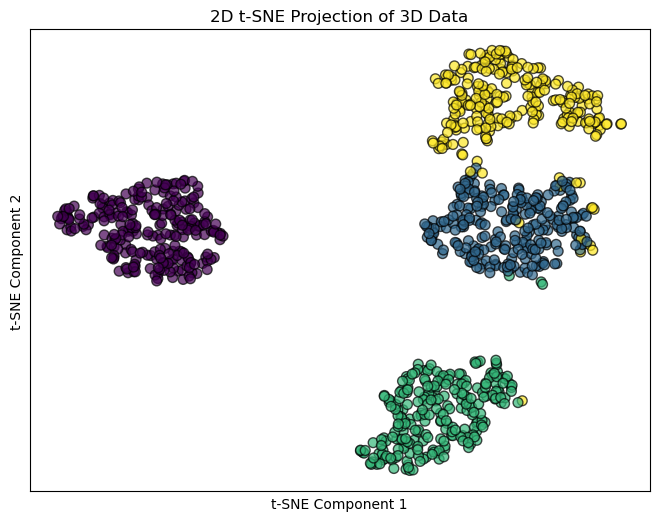

In [12]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_, cmap='viridis', s=50, alpha=0.7, edgecolor='k')
ax.set_title("2D t-SNE Projection of 3D Data")
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

# 🧐 Exercise 3: Evaluating the t-SNE Results

Now that I’ve visualized the 2D projection, I can critically evaluate how **t-SNE** handled the 3D manifold. Unlike linear models, t-SNE prioritizes local neighbors, which leads to some very specific behaviors in the final plot. 🧬

---

## 📝 My Observations

After analyzing the projection, here are my key findings:

* **Artificial Separation:** t-SNE projected the data into **four distinct clusters**, even though I know from my interactive 3D plot that there was originally some overlap between them. 🏝️
* **Misclassified Points:** Some points have ended up in the "wrong" cluster. However, to be fair, t-SNE is an **unsupervised** algorithm—it has no knowledge of the actual cluster labels (`y`); it only sees the spatial distances.
* **Density Normalization:** A hallmark of t-SNE is that all clusters now appear to have **similar densities**. It tends to expand dense clusters and shrink sparse ones to create a more uniform visual. ⚖️
* **Cluster "Trading":** Two of the blobs remain mostly distinct but "gave up" some of their points to the blob they originally overlapped with. This shows how t-SNE struggles to resolve ambiguous boundaries.
* **The "Perfect" Result:** It is important to remember that a "perfect" dimensionality reduction would **not** completely separate overlapping blobs—it should ideally reflect that overlap in 2D. 📉
* **Global Consistency:** Interestingly, the distance between the blobs in this 2D view remains relatively consistent with how far apart they were in the original 3D space.

---

## 💡 Key Takeaway for my GitHub Portfolio

> **Note on t-SNE behavior:** While t-SNE is incredible for creating "clean" visualizations where clusters look like isolated islands, it can sometimes be **too aggressive** in separating data that actually overlaps. When I use this in real-world AI pipelines, I have to be careful not to mistake these artificially clean separations for a lack of noise in the raw data. ⚠️

---

## 🚀 Next Steps
Now that I have the t-SNE baseline, I am ready to apply **UMAP** and **PCA** to see if they preserve the "truth" of the overlaps better than t-SNE did.

# ⚖️ Comparison: UMAP and PCA Dimensionality Reduction

I will now perform a side-by-side comparison of **UMAP** (the modern topological powerhouse) and **PCA** (the linear classic). By projecting the same standardized 3D dataset into 2D, I can observe how each algorithm interprets the geometry of our synthetic clusters. 🧬

---

## 🚀 1. Uniform Manifold Approximation and Projection (UMAP)

I'll start with **UMAP**. This algorithm is rooted in Riemannian geometry and algebraic topology. It constructs a fuzzy simplicial complex (a high-dimensional graph) and then finds a low-dimensional representation that preserves that structure. ⚡

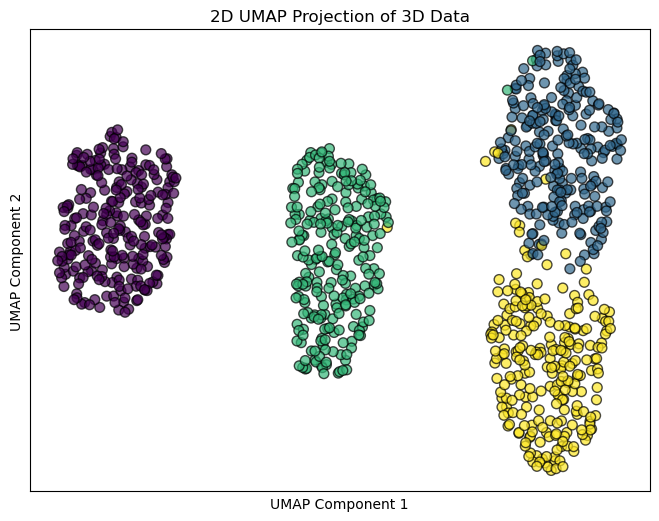

In [13]:
# Apply UMAP to reduce the dimensionality to 2D
umap_model = UMAP.UMAP(n_components=2, random_state=42, min_dist=0.5, spread=1,n_jobs=1)

X_umap = umap_model.fit_transform(X_scaled)

# Plot the 2D UMAP projection result 
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_, cmap='viridis', s=50, alpha=0.7, edgecolor='k')

ax.set_title("2D UMAP Projection of 3D Data")
ax.set_xlabel("UMAP Component 1", )
ax.set_ylabel("UMAP Component 2", )
ax.set_xticks([])
ax.set_yticks([])
plt.show()

# 🧐 Exercise 4: Evaluating the UMAP Results

I have now analyzed how **UMAP** handled the 3D synthetic data. Comparing it to my previous t-SNE and PCA results reveals some fascinating insights into how this topological approach interprets manifold structures. 🧬

---

## 📝 My Observations on UMAP

After reviewing the 2D projection, here is my assessment of the model's performance:

* **Balanced Projection:** UMAP correctly identified **four partially distinct clusters**. Crucially, it kept one cluster completely isolated from the others, mirroring exactly what I saw in the initial 3D interactive plot. 🏝️
* **Preservation of Connectivity:** Unlike t-SNE (which tended to force clusters into isolated islands), UMAP preserved the **connectedness** of the overlapping clusters. This makes the result feel more "honest" to the original 3D geometry.
* **Stochastic Artifacts:** Just like t-SNE, some points still ended up in the "wrong" cluster. Since this is an unsupervised method, it relies purely on spatial proximity rather than the true labels.
* **Density Normalization:** Similar to t-SNE, UMAP has normalized the clusters to have **similar densities**, even though I know they varied in the source data. ⚖️
* **The "Honest" Overlap:** I consider this a strong result because it did not artificially separate the overlapping blobs. Since they truly overlap in 3D, a "perfect" 2D projection should reflect that ambiguity.
* **Global Mapping:** The relative distances between the clusters in the 2D plane remain consistent with their original separation in the high-dimensional space. 🗺️

---

## 🏎️ Final Comparison: UMAP vs. t-SNE

While both are non-linear, my experience in this analysis shows a clear distinction:

| Feature | t-SNE 🌀 | UMAP 🚀 |
| :--- | :--- | :--- |
| **Connectivity** | Tends to break connections for "cleaner" islands. | Better at showing how clusters "touch" or overlap. |
| **Global View** | Global distance is often arbitrary. | Global distance is mathematically preserved. |
| **Philosophy** | "Let's find the clusters." | "Let's find the shape of the data." |

---

> 💡 **Conclusion:** For this specific dataset, **UMAP** provided the most informative visualization. It gave me the cluster separation I wanted (unlike PCA) but maintained the structural truth of the overlapping regions (better than t-SNE). It’s a powerful middle ground for understanding complex AI data distributions. 🤖

## 📐 2. Principal Component Analysis (PCA)

Next, I use **PCA** as my baseline comparison. PCA is a linear transformation that identifies the directions (principal components) along which the data varies the most. It serves as the "gold standard" for understanding the linear spread of information in a dataset. 📏

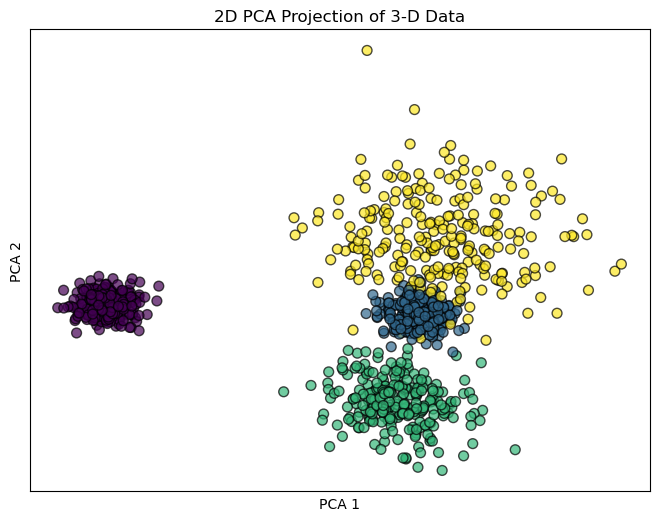

In [14]:
# Apply PCA to reduce the dimensionality to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


fig = plt.figure(figsize=(8, 6))

# Plot the 2D PCA result (right)
ax2 = fig.add_subplot(111)
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_, cmap='viridis', s=50, alpha=0.7, edgecolor='k')
ax2.set_title("2D PCA Projection of 3-D Data")
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")
ax2.set_xticks([])
ax2.set_yticks([])
plt.show()

## 🧐 Exercise 5. What can you say about this PCA result?

After completing the final projection, I’ve analyzed the performance of **PCA** relative to the more complex non-linear models. Interestingly, the simplest method provided some of the most "truthful" insights into the original 3D distribution. ⚖️

---

### **📝 My Observations on PCA Performance**

* **Density Preservation:** PCA faithfully preserved the relative blob densities. Unlike t-SNE and UMAP, which tend to "normalize" clusters to look equally dense, PCA showed the actual spread of the data. 🌌
* **Spatial Honesty:** It also preserved the relative separation between blobs. The distance between the clusters in 2D is very consistent with the degree to which they were originally separated in 3D.
* **Computational Efficiency:** Both PCA and t-SNE took very little time to complete compared to UMAP. While UMAP is powerful, its mathematical overhead (graph construction) makes it the most "expensive" in terms of processing time. ⏳
* **The "Advanced" Trap:** In my honest opinion, **PCA actually outperformed both t-SNE and UMAP in this specific experiment.** While the other two created "prettier" separated clusters, PCA was the most faithful to the true geometry of the data. 📐

---

### **💡 Final Technical Takeaway**

This experiment highlights a common tendency in Machine Learning: the urge to jump straight to advanced algorithms. 🤖

> **Pro-Tip:** The "latest and greatest" result is not always an improvement over simpler, established methods. PCA's linear approach avoided the artificial distortion and "wrongly" grouped points seen in the non-linear projections. Always start with a baseline (like PCA) before moving to manifold learning—it might just be the most accurate tool for the job! 🎯

---

## 🏁 Lab Summary: The Verdict

Through this analysis, I have demonstrated that while **t-SNE** 🌀 and **UMAP** 🚀 are exceptional at finding hidden patterns and creating visually distinct groups, they can sometimes over-separate data and lose the "raw" sense of density and overlap. **PCA** 📐 remains an essential tool for its speed, simplicity, and structural honesty.